## Backpropagation

* Implementing a two-layer artificial neural network using `numpy` and/or `torch`with two input neurons and one output neuron.
* Implementing a train function that runs the backpropagation algorithm.
* Our goal is to learn the XOR function. What does the network return for random weights of all combinations of (binary) inputs?

Reference: Rojas book (https://www.inf.fu-berlin.de/inst/ag-ki/rojas_home/documents/1996/NeuralNetworks/neuron.pdf), chapter 7.3.3 and learn about the "matrix way" of implementing backprop.

In [ ]:
import numpy as np
import torch

# Helper functions
def normalize(data, mean=None, variance=None, ret=False):
    """Normalizes the data to allow for faster convergence of the gradient ascent"""
    if mean is None:
        mean = np.mean(data, axis=0)[np.newaxis,:]
    if variance is None:
        std = np.std(data, axis=0)[np.newaxis,:]
    std[np.where(std == 0)] = 1
    data_ = (data - mean) / std
    if ret:
        return data_
    else:
        return data_, mean, std

def onehot(labels, k):
    n = len(labels)
    onehot_labels = np.zeros([n, k])
    onehot_labels[range(n), labels] = 1
    return onehot_labels

In [ ]:
class NN:
    # Two-layer NN: input(2) -> hidden(H) -> output(2)
    def __init__(self, n_in=2, n_hidden=4, n_out=2, lr=0.5, seed=None):
        self.n_in = n_in
        self.n_hidden = n_hidden
        self.n_out = n_out
        self.lr = lr

        rng = np.random.default_rng(seed)

        # Xavier-ish init
        self.W1 = rng.normal(0.0, 1.0/np.sqrt(n_in), size=(n_in, n_hidden))
        self.b1 = np.zeros((1, n_hidden))
        self.W2 = rng.normal(0.0, 1.0/np.sqrt(n_hidden), size=(n_hidden, n_out))
        self.b2 = np.zeros((1, n_out))

        # caches for forward/backward
        self.X = None
        self.Z1 = None
        self.A1 = None
        self.Z2 = None
        self.A2 = None

        # grads
        self.dW1 = None
        self.db1 = None
        self.dW2 = None
        self.db2 = None

    def sigmoid(self, z):
        z = np.clip(z, -50, 50)
        return 1.0 / (1.0 + np.exp(-z))

    def sigmoid_prime_from_a(self, a):
        # derivative of sigmoid using activation a = sigmoid(z)
        return a * (1.0 - a)

    def feedforward(self, X):
        """Feed-forward given input X and weight matrices."""
        self.X = X
        self.Z1 = X @ self.W1 + self.b1
        self.A1 = self.sigmoid(self.Z1)
        self.Z2 = self.A1 @ self.W2 + self.b2
        self.A2 = self.sigmoid(self.Z2)   # outputs in (0,1), suitable for MSE + one-hot
        return self.A2

    def loss(self, Y_pred, Y_true):
        # MSE (0.5 factor is optional; helps match classic derivations)
        return np.mean(0.5 * (Y_pred - Y_true) ** 2)

    def backprop(self, Y):
        """Compute gradients for current batch using cached forward pass."""
        N = self.X.shape[0]

        # dL/dA2 for MSE: (A2 - Y)/N, keep /N for stable scaling
        dA2 = (self.A2 - Y) / N
        dZ2 = dA2 * self.sigmoid_prime_from_a(self.A2)

        self.dW2 = self.A1.T @ dZ2
        self.db2 = np.sum(dZ2, axis=0, keepdims=True)

        dA1 = dZ2 @ self.W2.T
        dZ1 = dA1 * self.sigmoid_prime_from_a(self.A1)

        self.dW1 = self.X.T @ dZ1
        self.db1 = np.sum(dZ1, axis=0, keepdims=True)

    def optimize(self):
        """Update step."""
        self.W1 -= self.lr * self.dW1
        self.b1 -= self.lr * self.db1
        self.W2 -= self.lr * self.dW2
        self.b2 -= self.lr * self.db2

    def train(self, X, Y, iters=20000, tol=1e-3, verbose_every=2000):
        """Full-batch training (fine for XOR). Returns loss history."""
        losses = []
        for t in range(iters):
            Y_pred = self.feedforward(X)
            L = self.loss(Y_pred, Y)
            losses.append(L)

            self.backprop(Y)
            self.optimize()

            if verbose_every is not None and (t % verbose_every == 0):
                print(f"iter={t:6d}  loss={L:.6f}")

            if L < tol:
                print(f"Early stop at iter={t} with loss={L:.6f}")
                break

        return np.array(losses)

    def predict(self, X):
        return self.feedforward(X)

    def predict_class(self, X):
        return np.argmax(self.feedforward(X), axis=1)

In [ ]:
# XOR dataset
xor_data = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1],
])
xor_labels = onehot(np.array([0, 1, 1, 0]), 2)
print(xor_labels.shape)
print(xor_labels)

(4, 2)
[[1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]]


In [ ]:
# Using the given XOR dataset from the notebook
X = xor_data
Y = xor_labels

nn = NN(n_in=2, n_hidden=4, n_out=2, lr=0.5, seed=None)  # seed=None => random weights

print("Random-weight outputs (rows correspond to [0,0],[0,1],[1,0],[1,1]):")
print(nn.predict(X))
print("Predicted classes:", nn.predict_class(X))
print("True classes     :", np.argmax(Y, axis=1))


Random-weight outputs (rows correspond to [0,0],[0,1],[1,0],[1,1]):
[[0.35503771 0.3261984 ]
 [0.36077332 0.31466685]
 [0.29455427 0.30290366]
 [0.30494054 0.29518951]]
Predicted classes: [0 0 1 0]
True classes     : [0 1 1 0]


## Backpropagation_2

Implementing Backpropagation and optimizing the weights of the neural network using the XOR dataset:

| x | y |
| -------- | ------- |
| (0,0) | 0 |
| (0,1) | 1 |
| (1,0) | 1 |
| (1,1) | 0 |

* Plotting the network error over the number of iterations

In [ ]:
import matplotlib.pyplot as plt

iter=     0  loss=0.153436
iter=  5000  loss=0.000649
iter= 10000  loss=0.000255
iter= 15000  loss=0.000155
iter= 20000  loss=0.000111
Early stop at iter=21824 with loss=0.000100

Final outputs:
[[0.98362515 0.01614191]
 [0.01338324 0.98684392]
 [0.0136423  0.98604247]
 [0.98709242 0.01309326]]
Final predicted classes: [0 1 1 0]
True classes           : [0 1 1 0]
Training iterations used: 21825


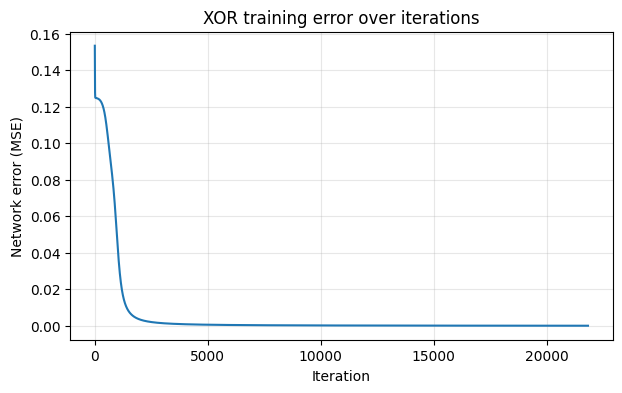

In [ ]:
nn = NN(n_in=2, n_hidden=4, n_out=2, lr=1.0, seed=0)

losses = nn.train(xor_data, xor_labels, iters=50000, tol=1e-4, verbose_every=5000)

print("\nFinal outputs:")
print(nn.predict(xor_data))
print("Final predicted classes:", nn.predict_class(xor_data))
print("True classes           :", np.argmax(xor_labels, axis=1))
print("Training iterations used:", len(losses))

plt.figure(figsize=(7,4))
plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("Network error (MSE)")
plt.title("XOR training error over iterations")
plt.grid(True, alpha=0.3)
plt.show()


## MNIST

* Training the network on the [MNIST dataset](http://yann.lecun.com/exdb/mnist/) and noting the model accuracy (or the model error) for the training and test sets.
* Compare to this [list](https://rodrigob.github.io/are_we_there_yet/build/classification_datasets_results.html#4d4e495354) and report on the performance of the model.

In [ ]:
# You can access MNIST using torchvision (https://pytorch.org/vision/main/generated/torchvision.datasets.MNIST.html)
import torchvision.datasets as datasets

mnist_train = datasets.MNIST(root='./data', train=True, download=True, transform=None)
mnist_test = datasets.MNIST(root='./data', train=False, download=True, transform=None)

mnist_train_data = mnist_train.data.numpy()
mnist_train_labels = mnist_train.targets.numpy()
mnist_test_data = mnist_test.data.numpy()
mnist_test_labels = mnist_test.targets.numpy()

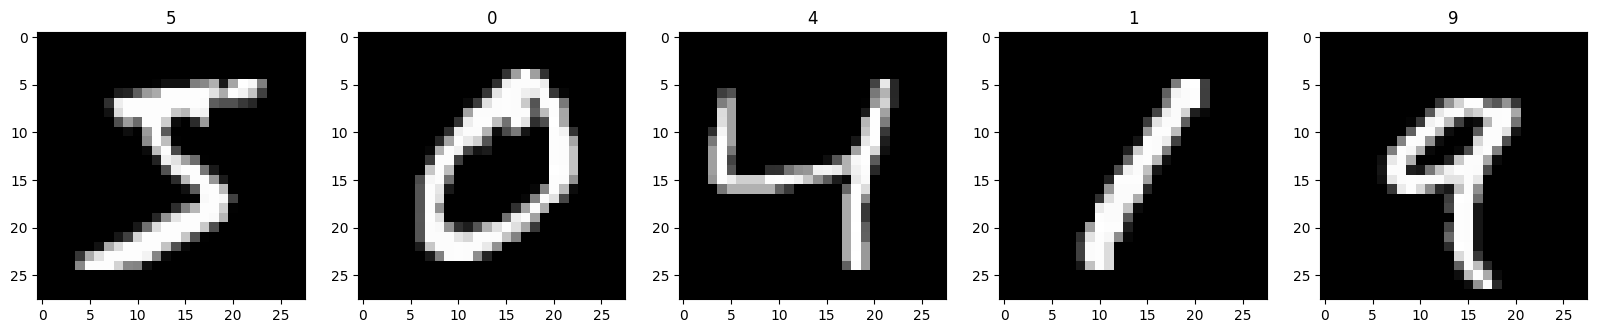

In [ ]:
images, labels = mnist_train_data[:5], mnist_train_labels[:5]

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for i in range(5):
    axes[i].set_title(labels[i])
    axes[i].imshow(images[i], cmap='gray')

In [ ]:
mnist_train_data_, mean, mu = normalize(mnist_train_data.reshape([-1, 28*28]))
mnist_train_labels_ = onehot(mnist_train_labels, 10)

In [ ]:
class NN_MNIST:
    def __init__(self, n_in=28*28, n_hidden=128, n_out=10, lr=0.1, seed=0):
        self.n_in = n_in
        self.n_hidden = n_hidden
        self.n_out = n_out
        self.lr = lr

        rng = np.random.default_rng(seed)

        # Xavier-ish init
        self.W1 = rng.normal(0.0, 1.0/np.sqrt(n_in), size=(n_in, n_hidden))
        self.b1 = np.zeros((1, n_hidden))
        self.W2 = rng.normal(0.0, 1.0/np.sqrt(n_hidden), size=(n_hidden, n_out))
        self.b2 = np.zeros((1, n_out))

    def sigmoid(self, z):
        z = np.clip(z, -50, 50)
        return 1.0 / (1.0 + np.exp(-z))

    def sigmoid_prime_from_a(self, a):
        return a * (1.0 - a)

    def feedforward(self, X):
        self.X = X
        self.Z1 = X @ self.W1 + self.b1
        self.A1 = self.sigmoid(self.Z1)
        self.Z2 = self.A1 @ self.W2 + self.b2
        self.A2 = self.sigmoid(self.Z2)
        return self.A2

    def loss(self, Y_pred, Y_true):
        return np.mean(0.5 * (Y_pred - Y_true) ** 2)

    def backprop(self, Y):
        N = self.X.shape[0]
        # dL/dA2
        dA2 = (self.A2 - Y) / N
        dZ2 = dA2 * self.sigmoid_prime_from_a(self.A2)

        self.dW2 = self.A1.T @ dZ2
        self.db2 = np.sum(dZ2, axis=0, keepdims=True)

        dA1 = dZ2 @ self.W2.T
        dZ1 = dA1 * self.sigmoid_prime_from_a(self.A1)

        self.dW1 = self.X.T @ dZ1
        self.db1 = np.sum(dZ1, axis=0, keepdims=True)

    def optimize(self):
        self.W1 -= self.lr * self.dW1
        self.b1 -= self.lr * self.db1
        self.W2 -= self.lr * self.dW2
        self.b2 -= self.lr * self.db2

    def train_epoch(self, X, Y, batch_size=128):
        # One epoch of mini-batch GD
        N = X.shape[0]
        idx = np.random.permutation(N)
        X = X[idx]
        Y = Y[idx]

        losses = []
        for start in range(0, N, batch_size):
            end = start + batch_size
            xb = X[start:end]
            yb = Y[start:end]

            y_pred = self.feedforward(xb)
            L = self.loss(y_pred, yb)
            self.backprop(yb)
            self.optimize()
            losses.append(L)

        return np.mean(losses)

    def predict(self, X):
        return self.feedforward(X)

    def predict_class(self, X):
        return np.argmax(self.feedforward(X), axis=1)


# ---- Prepare train & test data ----

# Prepare test data using same normalization parameters
mnist_test_data_ = normalize(mnist_test_data.reshape([-1, 28*28]), mean=mean, variance=None, ret=True)
mnist_test_labels_ = onehot(mnist_test_labels, 10)

X_train = mnist_train_data_
Y_train = mnist_train_labels_
X_test = mnist_test_data_
Y_test = mnist_test_labels_

print("Train shape:", X_train.shape, Y_train.shape)
print("Test shape :", X_test.shape, Y_test.shape)

# ---- Train the network ----

model = NN_MNIST(n_in=28*28, n_hidden=128, n_out=10, lr=0.1, seed=0)

num_epochs = 40
batch_size = 128
train_losses = []

for epoch in range(num_epochs):
    loss_epoch = model.train_epoch(X_train, Y_train, batch_size=batch_size)
    train_losses.append(loss_epoch)

    # compute train accuracy
    train_pred = model.predict_class(X_train)
    train_true = np.argmax(Y_train, axis=1)
    train_acc = np.mean(train_pred == train_true)

    # compute test accuracy
    test_pred = model.predict_class(X_test)
    test_true = np.argmax(Y_test, axis=1)
    test_acc = np.mean(test_pred == test_true)

    print(f"Epoch {epoch+1}/{num_epochs} - loss={loss_epoch:.4f} "
          f"- train_acc={train_acc*100:.2f}% - test_acc={test_acc*100:.2f}%")

print("\nFinal results:")
print(f"Train accuracy: {train_acc*100:.2f}%")
print(f"Test accuracy : {test_acc*100:.2f}%")
print(f"Train error   : {100 - train_acc*100:.2f}%")
print(f"Test error    : {100 - test_acc*100:.2f}%")


Train shape: (60000, 784) (60000, 10)
Test shape : (10000, 784) (10000, 10)
Epoch 1/40 - loss=0.0315 - train_acc=82.01% - test_acc=83.14%
Epoch 2/40 - loss=0.0173 - train_acc=86.91% - test_acc=87.45%
Epoch 3/40 - loss=0.0132 - train_acc=88.62% - test_acc=89.14%
Epoch 4/40 - loss=0.0113 - train_acc=89.42% - test_acc=89.93%
Epoch 5/40 - loss=0.0102 - train_acc=90.11% - test_acc=90.32%
Epoch 6/40 - loss=0.0095 - train_acc=90.51% - test_acc=90.67%
Epoch 7/40 - loss=0.0089 - train_acc=90.88% - test_acc=90.97%
Epoch 8/40 - loss=0.0085 - train_acc=91.20% - test_acc=91.22%
Epoch 9/40 - loss=0.0081 - train_acc=91.42% - test_acc=91.39%
Epoch 10/40 - loss=0.0078 - train_acc=91.66% - test_acc=91.63%
Epoch 11/40 - loss=0.0076 - train_acc=91.85% - test_acc=91.82%
Epoch 12/40 - loss=0.0074 - train_acc=92.06% - test_acc=91.96%
Epoch 13/40 - loss=0.0072 - train_acc=92.22% - test_acc=92.14%
Epoch 14/40 - loss=0.0070 - train_acc=92.38% - test_acc=92.38%
Epoch 15/40 - loss=0.0069 - train_acc=92.52% - test